<a href="https://colab.research.google.com/github/abdulazoor/northstar-databases-analytics/blob/main/notebooks/02_Python_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NORTHSTAR ANALYTICS PROJECT
# 02_PYTHON_ANALYTICS.IPYNB
# Data Processing, Feature Engineering and Advanced Analytics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("Python analytics environment loaded successfully.")

Python analytics environment loaded successfully.


In [ ]:
# ============================================================
# 1. IMPORT DATASETS
# ============================================================

customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")

print("All datasets imported successfully.")

All datasets imported successfully.


In [ ]:
# ============================================================
# 2. DATASET OVERVIEW
# ============================================================

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events,
    "data_dictionary": data_dictionary
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print(df.head())


CUSTOMERS
Rows: 650
Columns: 9
  customer_id  age  home_zone customer_type          signup_date  \
0       C0001   26      North           SME  2024-11-27 04:25:00   
1       C0002   61    AIRPORT      Consumer  2025-10-28 01:04:00   
2       C0003   66       East      Consumer  2025-07-02 03:23:00   
3       C0004   75    CENTRAL      Consumer  2025-08-19 01:58:00   
4       C0005   26  Riverside      Consumer  2025-06-03 06:02:00   

   loyalty_score  app_engagement_score preferred_channel account_status  
0           44.9                  69.2               App         Active  
1           55.4                  66.6               App         Active  
2           75.9                  33.8               NaN         Active  
3           32.5                  33.0               App         Active  
4           55.9                 100.0               Web         Active  

ORDERS
Rows: 1250
Columns: 11
  order_id customer_id service_type     order_created_at  \
0   O00001       C0292  

In [ ]:
# ============================================================
# 3. MISSING VALUE ANALYSIS
# ============================================================

missing_report = []

for name, df in datasets.items():
    for column in df.columns:
        missing_report.append({
            "dataset": name,
            "column": column,
            "missing_values": df[column].isnull().sum(),
            "missing_percentage": round((df[column].isnull().sum() / len(df)) * 100, 2)
        })

missing_df = pd.DataFrame(missing_report)

missing_df.sort_values(
    by="missing_values",
    ascending=False
).head(30)

,dataset,column,missing_values,missing_percentage
73,app_events,order_id,144,22.50
18,orders,booking_channel,25,2.00
5,customers,loyalty_score,20,3.08
26,deliveries,delivery_completed_at,19,2.00
70,incidents,resolved_hours,17,6.07
63,complaints,compensation_amount,16,5.00
31,deliveries,customer_rating_post_delivery,14,1.47
7,customers,preferred_channel,13,2.00
37,drivers,training_score,7,4.12
45,vehicles,battery_health_pct,4,3.33


In [ ]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

# Standardise delivery status
deliveries["delivery_status"] = deliveries["delivery_status"].astype(str).str.strip()

deliveries["delivery_status"] = deliveries["delivery_status"].replace({
    "Delay": "Delayed",
    "Late": "Delayed",
    "Delivery Delayed": "Delayed",
    "Failure": "Failed",
    "Complete": "Completed",
    "Success": "Completed"
})

# Fill missing customer ratings using median
if "customer_rating_post_delivery" in deliveries.columns:
    deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
        deliveries["customer_rating_post_delivery"].median()
    )

# Fill missing complaint fields
if "complaint_type" in complaints.columns:
    complaints["complaint_type"] = complaints["complaint_type"].fillna("No Complaint")

if "severity" in complaints.columns:
    complaints["severity"] = complaints["severity"].fillna("No Complaint")

if "resolution_days" in complaints.columns:
    complaints["resolution_days"] = complaints["resolution_days"].fillna(0)

if "compensation_amount" in complaints.columns:
    complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

# Fill missing incident fields
if "incident_type" in incidents.columns:
    incidents["incident_type"] = incidents["incident_type"].fillna("No Incident")

if "severity" in incidents.columns:
    incidents["severity"] = incidents["severity"].fillna("No Incident")

if "resolved_hours" in incidents.columns:
    incidents["resolved_hours"] = incidents["resolved_hours"].fillna(0)

print("Data cleaning completed successfully.")

Data cleaning completed successfully.


In [ ]:
# ============================================================
# 5. DATASET INTEGRATION
# ============================================================

merged_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

merged_df = merged_df.merge(
    deliveries,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    hubs,
    on="hub_id",
    how="left"
)

merged_df = merged_df.merge(
    vehicles,
    on="vehicle_id",
    how="left"
)

merged_df = merged_df.merge(
    drivers,
    on="driver_id",
    how="left"
)

merged_df = merged_df.merge(
    complaints,
    on="order_id",
    how="left",
    suffixes=("", "_complaint")
)

merged_df = merged_df.merge(
    incidents,
    on="delivery_id",
    how="left",
    suffixes=("", "_incident")
)

print("Integrated dataset created successfully.")
print("Rows:", merged_df.shape[0])
print("Columns:", merged_df.shape[1])

merged_df.head()

Integrated dataset created successfully.
Rows: 1318
Columns: 64


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,created_at,status,resolution_days,compensation_amount,incident_id,incident_type,reported_at,severity_incident,resolution_status,resolved_hours
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,2025-09-07 14:37:00,Open,2.0,8.66,NaN,NaN,NaN,NaN,NaN,NaN
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,2025-02-25 19:32:00,Resolved,8.0,54.41,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

merged_df["delay_flag"] = np.where(
    merged_df["delivery_status"] == "Delayed",
    1,
    0
)

merged_df["failure_flag"] = np.where(
    merged_df["delivery_status"] == "Failed",
    1,
    0
)

merged_df["complaint_flag"] = np.where(
    merged_df["complaint_type"].notna(),
    1,
    0
)

merged_df["incident_flag"] = np.where(
    merged_df["incident_type"].notna(),
    1,
    0
)

merged_df["maintenance_risk"] = np.where(
    merged_df["maintenance_status"] == "InRepair",
    1,
    0
)

merged_df["route_override_risk"] = np.where(
    merged_df["manual_route_override_count"] >= 2,
    1,
    0
)

merged_df["high_severity_complaint"] = np.where(
    merged_df["severity"] == "High",
    1,
    0
)

merged_df["operational_risk_score"] = (
    merged_df["delay_flag"] +
    merged_df["failure_flag"] +
    merged_df["complaint_flag"] +
    merged_df["incident_flag"] +
    merged_df["maintenance_risk"] +
    merged_df["route_override_risk"] +
    merged_df["high_severity_complaint"]
)

print("Feature engineering completed successfully.")

merged_df[
    [
        "delivery_status",
        "delay_flag",
        "failure_flag",
        "complaint_flag",
        "incident_flag",
        "maintenance_risk",
        "route_override_risk",
        "high_severity_complaint",
        "operational_risk_score"
    ]
].head()

Feature engineering completed successfully.


,delivery_status,delay_flag,failure_flag,complaint_flag,incident_flag,maintenance_risk,route_override_risk,high_severity_complaint,operational_risk_score
0,OnTime,0,0,0,0,1,1,0,2
1,NaN,0,0,0,0,0,0,0,0
2,Delayed,1,0,1,0,0,1,0,3
3,OnTime,0,0,0,0,0,0,0,0
4,OnTime,0,0,1,0,0,0,0,1


In [ ]:
# ============================================================
# 7. HUB-LEVEL PERFORMANCE ANALYSIS
# ============================================================

hub_analysis = merged_df.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    delayed_deliveries=("delay_flag", "sum"),
    failed_deliveries=("failure_flag", "sum"),
    complaints=("complaint_flag", "sum"),
    incidents=("incident_flag", "sum"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_route_overrides=("manual_route_override_count", "mean"),
    avg_operational_risk=("operational_risk_score", "mean")
).reset_index()

hub_analysis["delay_rate_pct"] = round(
    (hub_analysis["delayed_deliveries"] / hub_analysis["total_deliveries"]) * 100,
    2
)

hub_analysis["failure_rate_pct"] = round(
    (hub_analysis["failed_deliveries"] / hub_analysis["total_deliveries"]) * 100,
    2
)

hub_analysis["complaint_rate_pct"] = round(
    (hub_analysis["complaints"] / hub_analysis["total_deliveries"]) * 100,
    2
)

hub_analysis.sort_values(
    by="avg_operational_risk",
    ascending=False
)

,hub_id,hub_name,zone,total_deliveries,delayed_deliveries,failed_deliveries,complaints,incidents,avg_customer_rating,avg_route_overrides,avg_operational_risk,delay_rate_pct,failure_rate_pct,complaint_rate_pct
4,H05,Central Core,Central,122,26,24,30,39,3.681885,0.942623,1.590164,21.31,19.67,24.59
6,H07,Riverside Hub,Riverside,121,25,16,34,35,3.882645,1.024793,1.578512,20.66,13.22,28.10
7,H08,Midtown Relay,Central,138,25,27,36,41,3.904420,1.050725,1.557971,18.12,19.57,26.09
5,H06,Airport Hub,Airport,113,28,16,26,32,3.901327,0.884956,1.477876,24.78,14.16,23.01
2,H03,East Dock,East,128,23,12,36,40,3.914766,0.859375,1.468750,17.97,9.38,28.12
3,H04,West Gate,West,130,30,16,28,35,3.903462,0.861538,1.330769,23.08,12.31,21.54
0,H01,North Exchange,North,143,26,18,32,33,3.843776,1.020979,1.307692,18.18,12.59,22.38
1,H02,South Link,South,111,27,10,18,33,3.938559,0.927928,1.234234,24.32,9.01,16.22


In [ ]:
# ============================================================
# 8. ROUTE OVERRIDE ANALYSIS
# ============================================================

route_override_analysis = merged_df.groupby("manual_route_override_count").agg(
    total_deliveries=("delivery_id", "count"),
    delayed_deliveries=("delay_flag", "sum"),
    failed_deliveries=("failure_flag", "sum"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_operational_risk=("operational_risk_score", "mean")
).reset_index()

route_override_analysis["disruption_rate_pct"] = round(
    (
        (route_override_analysis["delayed_deliveries"] +
         route_override_analysis["failed_deliveries"])
        / route_override_analysis["total_deliveries"]
    ) * 100,
    2
)

route_override_analysis

,manual_route_override_count,total_deliveries,delayed_deliveries,failed_deliveries,avg_customer_rating,avg_operational_risk,disruption_rate_pct
0,0.0,428,81,49,3.912827,1.257009,30.37
1,1.0,331,70,55,3.882054,1.193353,37.76
2,2.0,158,36,22,3.829747,2.094937,36.71
3,3.0,58,14,10,3.667414,2.189655,41.38
4,4.0,23,5,3,3.865652,1.956522,34.78
5,5.0,7,4,0,3.378571,2.142857,57.14
6,7.0,1,0,0,4.010000,1.000000,0.00


In [ ]:
# ============================================================
# 9. VEHICLE MAINTENANCE ANALYSIS
# ============================================================

vehicle_maintenance_analysis = merged_df.groupby("maintenance_status").agg(
    total_deliveries=("delivery_id", "count"),
    delayed_deliveries=("delay_flag", "sum"),
    failed_deliveries=("failure_flag", "sum"),
    avg_battery_health=("battery_health_pct", "mean"),
    avg_odometer=("odometer_km", "mean"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_operational_risk=("operational_risk_score", "mean")
).reset_index()

vehicle_maintenance_analysis["disruption_rate_pct"] = round(
    (
        (vehicle_maintenance_analysis["delayed_deliveries"] +
         vehicle_maintenance_analysis["failed_deliveries"])
        / vehicle_maintenance_analysis["total_deliveries"]
    ) * 100,
    2
)

vehicle_maintenance_analysis.sort_values(
    by="disruption_rate_pct",
    ascending=False
)

,maintenance_status,total_deliveries,delayed_deliveries,failed_deliveries,avg_battery_health,avg_odometer,avg_customer_rating,avg_operational_risk,disruption_rate_pct
1,InRepair,274,55,82,76.378832,119530.109489,3.650766,2.386861,50.00
2,Scheduled,162,39,11,78.712346,129855.858025,3.901481,1.172840,30.86
0,Active,570,116,46,76.412132,109856.717544,3.967860,1.066667,28.42


In [ ]:
# ============================================================
# 10. COMPLAINT ESCALATION ANALYSIS
# ============================================================

complaint_escalation_analysis = merged_df.groupby("severity").agg(
    total_records=("order_id", "count"),
    total_complaints=("complaint_flag", "sum"),
    failed_related=("failure_flag", "sum"),
    delayed_related=("delay_flag", "sum"),
    avg_resolution_days=("resolution_days", "mean"),
    avg_compensation=("compensation_amount", "mean"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_operational_risk=("operational_risk_score", "mean")
).reset_index()

complaint_escalation_analysis.sort_values(
    by="avg_operational_risk",
    ascending=False
)

,severity,total_records,total_complaints,failed_related,delayed_related,avg_resolution_days,avg_compensation,avg_customer_rating,avg_operational_risk
0,High,78,78,13,12,13.166667,34.077179,3.744815,2.884615
2,Medium,176,176,18,30,6.170455,16.686648,3.974672,1.926136
1,Low,74,74,5,6,6.445946,8.586081,4.033878,1.662162


In [ ]:
# ============================================================
# 11. EXPORT PROCESSED DATASET
# ============================================================

merged_df.to_csv("northstar_processed_dataset.csv", index=False)
hub_analysis.to_csv("hub_analysis.csv", index=False)
route_override_analysis.to_csv("route_override_analysis.csv", index=False)
vehicle_maintenance_analysis.to_csv("vehicle_maintenance_analysis.csv", index=False)
complaint_escalation_analysis.to_csv("complaint_escalation_analysis.csv", index=False)

print("Processed datasets exported successfully.")

Processed datasets exported successfully.


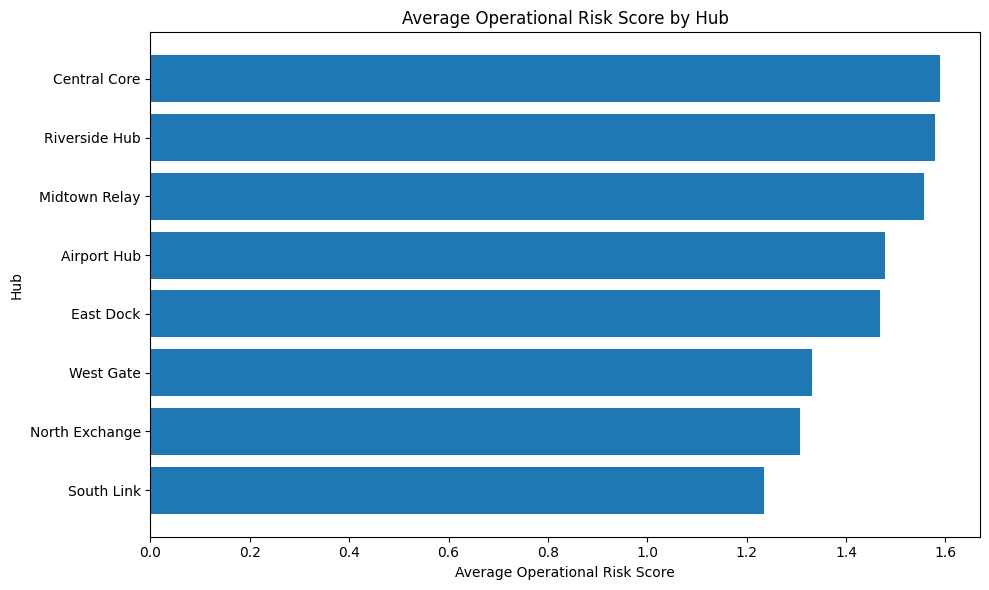

In [ ]:
# ============================================================
# 12. VISUALISATION: OPERATIONAL RISK BY HUB
# ============================================================

hub_plot = hub_analysis.sort_values(
    by="avg_operational_risk",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(hub_plot["hub_name"], hub_plot["avg_operational_risk"])
plt.title("Average Operational Risk Score by Hub")
plt.xlabel("Average Operational Risk Score")
plt.ylabel("Hub")
plt.tight_layout()
plt.savefig("operational_risk_by_hub.png", dpi=300)
plt.show()

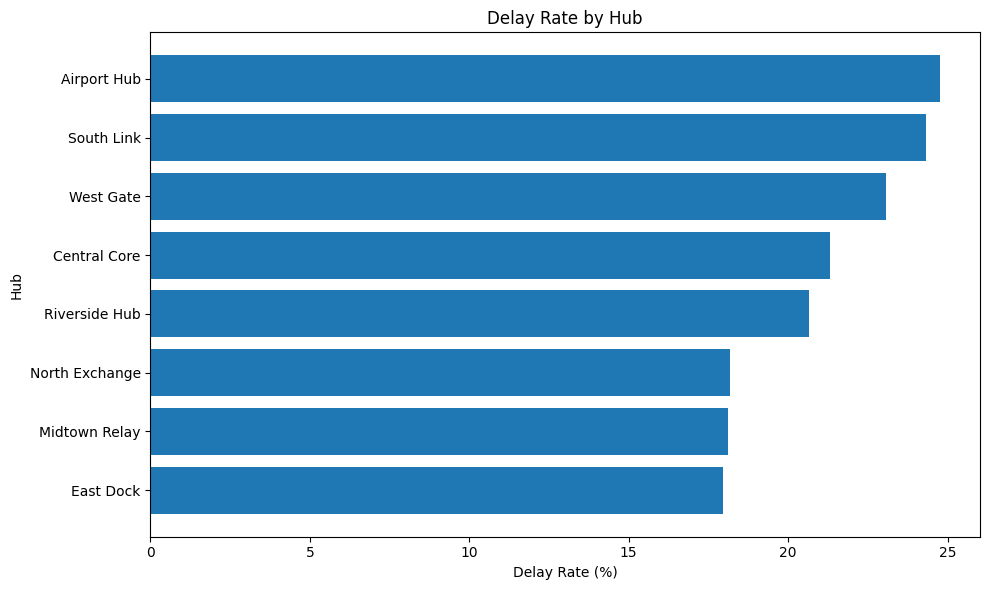

In [ ]:
# ============================================================
# 13. VISUALISATION: DELAY RATE BY HUB
# ============================================================

delay_plot = hub_analysis.sort_values(
    by="delay_rate_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(delay_plot["hub_name"], delay_plot["delay_rate_pct"])
plt.title("Delay Rate by Hub")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Hub")
plt.tight_layout()
plt.savefig("delay_rate_by_hub.png", dpi=300)
plt.show()

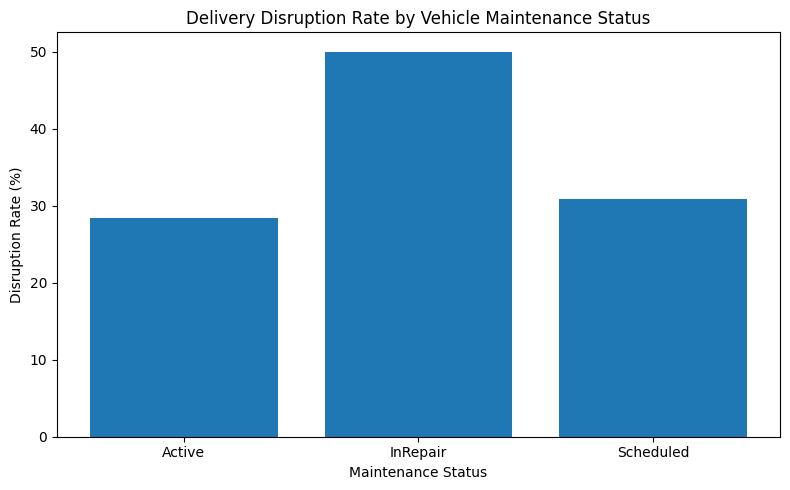

In [ ]:
# ============================================================
# 14. VISUALISATION: VEHICLE MAINTENANCE DISRUPTION
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(
    vehicle_maintenance_analysis["maintenance_status"],
    vehicle_maintenance_analysis["disruption_rate_pct"]
)
plt.title("Delivery Disruption Rate by Vehicle Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Disruption Rate (%)")
plt.tight_layout()
plt.savefig("vehicle_maintenance_disruption.png", dpi=300)
plt.show()

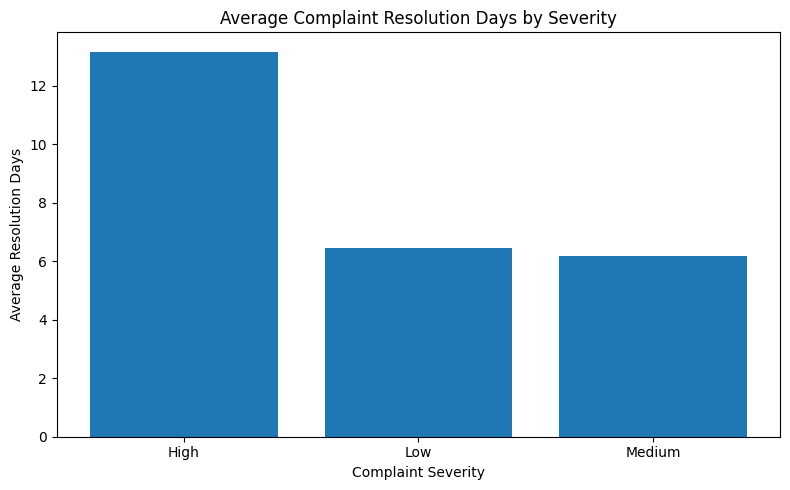

In [ ]:
# ============================================================
# 15. VISUALISATION: COMPLAINT RESOLUTION BY SEVERITY
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(
    complaint_escalation_analysis["severity"].astype(str),
    complaint_escalation_analysis["avg_resolution_days"]
)
plt.title("Average Complaint Resolution Days by Severity")
plt.xlabel("Complaint Severity")
plt.ylabel("Average Resolution Days")
plt.tight_layout()
plt.savefig("complaint_resolution_by_severity.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# 16. CORRELATION ANALYSIS
# ============================================================

risk_columns = [
    "delay_flag",
    "failure_flag",
    "complaint_flag",
    "incident_flag",
    "maintenance_risk",
    "route_override_risk",
    "high_severity_complaint",
    "operational_risk_score"
]

correlation_matrix = merged_df[risk_columns].corr()

correlation_matrix

,delay_flag,failure_flag,complaint_flag,incident_flag,maintenance_risk,route_override_risk,high_severity_complaint,operational_risk_score
delay_flag,1.000000,-0.149482,-0.020431,0.050731,0.057948,0.104362,-0.003760,0.359000
failure_flag,-0.149482,1.000000,0.008046,0.027657,0.323256,0.056658,0.049977,0.392463
complaint_flag,-0.020431,0.008046,1.000000,-0.041075,0.038107,-0.015599,0.435730,0.474272
incident_flag,0.050731,0.027657,-0.041075,1.000000,0.127264,-0.013986,-0.047029,0.415336
maintenance_risk,0.057948,0.323256,0.038107,0.127264,1.000000,0.027075,0.037911,0.558046
route_override_risk,0.104362,0.056658,-0.015599,-0.013986,0.027075,1.000000,-0.021568,0.398617
high_severity_complaint,-0.003760,0.049977,0.435730,-0.047029,0.037911,-0.021568,1.000000,0.386503
operational_risk_score,0.359000,0.392463,0.474272,0.415336,0.558046,0.398617,0.386503,1.000000
